# HAR TFM GRU

In [1]:
import pandas as pd
import numpy as np
import json

import math

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics

ruta_archivo_csv = "../../Procesamiento Datos/Dataset/HAR_TFM.csv.gz"

df = pd.read_csv(ruta_archivo_csv)
print(df)

              Ax        Ay        Az       Gx        Gy        Gz          Mx  \
0       0.028037  0.272983  0.938547 -0.85745  1.530512 -1.285625   16.856251   
1       0.036297 -1.118226 -0.264005 -0.61710  0.379362 -0.267025  362.943756   
2       0.032427  0.145508  1.354897 -1.07635 -1.441825  0.696025    0.356250   
3       0.370183  0.204207  0.954832 -0.37954 -0.559665 -0.238312  -25.068750   
4       1.329001 -0.985352  0.107682  1.72095 -1.653575 -1.253725  -39.600002   
...          ...       ...       ...      ...       ...       ...         ...   
365995  0.177876  0.465430  0.859490 -0.09094  0.068109  0.005574  -19.800001   
365996  0.351190 -0.832287 -0.448884 -0.00990 -0.000825  0.009762   32.812500   
365997  1.014918 -0.141639  0.255638  0.01265  0.007700  0.000137    3.187500   
365998  1.009626 -0.294183 -0.150097  0.02640  0.024750  0.030938   36.000000   
365999  0.230048 -0.802216 -0.552589 -0.00770 -0.023100 -0.003025  -15.356251   

               My         M

# Modelo Gated Recurrent Unit (GRU)

In [2]:
features = ['Az', 'AyGx','AxGx','AyGy','AxGy','AzGx','Mxz','MyGx','AyMz','Ayz','Mz','Ax','My','Gzy','Ay','MxGx','MxGy','Myz','Mx','AyMx','AzMx','Gz']

In [3]:
#Para ver la mayor corelación
X_orig = df[features]
y = df['activity']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 366000
Número de columnas: 22


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time


# Normalización de las características
scaler = StandardScaler()
X = scaler.fit_transform(X_orig)

# Codificación de etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convertir a formato categórico (one-hot encoding)
y_categorical = to_categorical(y_encoded)

# Ajustar las dimensiones de las entradas para GRU
X = np.expand_dims(X, axis=2)

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Si tienes 22 características y 1 timestep, deberías hacer:
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Paso 2: Definir el modelo GRU
model_GRU = Sequential()
model_GRU.add(GRU(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
model_GRU.add(GRU(128))
# Capa de salida: con activación softmax para clasificación multiclase (6 clases)
model_GRU.add(Dense(6, activation='softmax'))

# Compilar el modelo
model_GRU.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Paso 3: Entrenar el modelo

# Inicio del entrenamiento
inicio = time.time()
history = model_GRU.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)
# Fin del entrenamiento
fin = time.time()

tiempo_entrenamiento = fin - inicio


2026-08-23 17:58:35.271798: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-23 17:58:35.275108: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-23 17:58:35.318966: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-23 17:58:35.319485: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-23 17:58:36.142255: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

Epoch 1/20
7320/7320 [==============================] - 57s 8ms/step - loss: 0.5490 - accuracy: 0.8022 - val_loss: 0.4021 - val_accuracy: 0.8561
Epoch 2/20
7320/7320 [==============================] - 53s 7ms/step - loss: 0.3637 - accuracy: 0.8690 - val_loss: 0.3398 - val_accuracy: 0.8779
Epoch 3/20
7320/7320 [==============================] - 53s 7ms/step - loss: 0.3202 - accuracy: 0.8853 - val_loss: 0.3176 - val_accuracy: 0.8873
Epoch 4/20
7320/7320 [==============================] - 53s 7ms/step - loss: 0.2948 - accuracy: 0.8945 - val_loss: 0.2994 - val_accuracy: 0.8945
Epoch 5/20
7320/7320 [==============================] - 53s 7ms/step - loss: 0.2763 - accuracy: 0.9010 - val_loss: 0.2862 - val_accuracy: 0.8981
Epoch 6/20
7320/7320 [==============================] - 54s 7ms/step - loss: 0.2615 - accuracy: 0.9063 - val_loss: 0.2801 - val_accuracy: 0.9010
Epoch 7/20
7320/7320 [==============================] - 54s 7ms/step - loss: 0.2495 - accuracy: 0.9102 - val_loss: 0.2736 - val_ac

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Paso 1: Realizar las predicciones en el conjunto de prueba
y_pred_prob = model_GRU.predict(X_test)  # Obtiene probabilidades
y_pred = np.argmax(y_pred_prob, axis=1)  # Convierte a etiquetas de clase

# Paso 2: Convertir las etiquetas verdaderas a formato de clase
y_test_classes = np.argmax(y_test, axis=1)

# Paso 3: Calcular las métricas de evaluación
accuracy = accuracy_score(y_test_classes, y_pred)
precision = precision_score(y_test_classes, y_pred, average='weighted')
recall = recall_score(y_test_classes, y_pred, average='weighted')
f1 = f1_score(y_test_classes, y_pred, average='weighted')

# Paso 4: Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print(f"Tiempo de entrenamiento del GRU: {tiempo_entrenamiento/60:.2f} minutos")

2288/2288 [==============================] - 8s 3ms/step
Accuracy: 0.9168715846994535
Precision: 0.9177295510748721
Recall: 0.9168715846994535
F1 Score: 0.917180278994568
Tiempo de entrenamiento del GRU: 17.84 minutos


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

Labels = ['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

# Paso 1: Inicializar listas para almacenar las métricas
num_labels = len(Labels)
accuracy_per_label = []
precision_per_label = []
recall_per_label = []
f1_per_label = []

# Paso 2: Calcular las métricas de evaluación para cada etiqueta
for label_idx in range(num_labels):
    y_true_label = (y_test_classes == label_idx).astype(int)
    y_pred_label = (y_pred == label_idx).astype(int)

    accuracy_per_label.append(accuracy_score(y_true_label, y_pred_label))
    precision_per_label.append(precision_score(y_true_label, y_pred_label, zero_division=0))
    recall_per_label.append(recall_score(y_true_label, y_pred_label, zero_division=0))
    f1_per_label.append(f1_score(y_true_label, y_pred_label, zero_division=0))

# Paso 3: Imprimir los resultados por etiqueta
for label_idx in range(num_labels):
    print(f'Label: {Labels[label_idx]}')
    print('Accuracy:', accuracy_per_label[label_idx])
    print('Precision:', precision_per_label[label_idx])
    print('Recall:', recall_per_label[label_idx])
    print('F1 Score:', f1_per_label[label_idx])
    print()

Label: Caminar
Accuracy: 0.9466939890710383
Precision: 0.8476881989651144
Recall: 0.8302272355729933
F1 Score: 0.8388668648827221

Label: Metro
Accuracy: 0.9829508196721312
Precision: 0.9461443298969072
Recall: 0.9506919698350874
F1 Score: 0.9484126984126984

Label: Bus
Accuracy: 0.9830191256830602
Precision: 0.9568285595682856
Recall: 0.9409699542782495
F1 Score: 0.9488329971596757

Label: Conducir coche
Accuracy: 0.9947404371584699
Precision: 0.9854717597127
Recall: 0.9831446950574058
F1 Score: 0.9843068519952717

Label: Subir o bajar escaleras
Accuracy: 0.9426912568306011
Precision: 0.8122021717053355
Recall: 0.8530521824745652
F1 Score: 0.8321261354996199

Label: Estar detenido
Accuracy: 0.9836475409836065
Precision: 0.9578991246352647
Recall: 0.9431948776883927
F1 Score: 0.9504901352525127



## Matriz de confusión

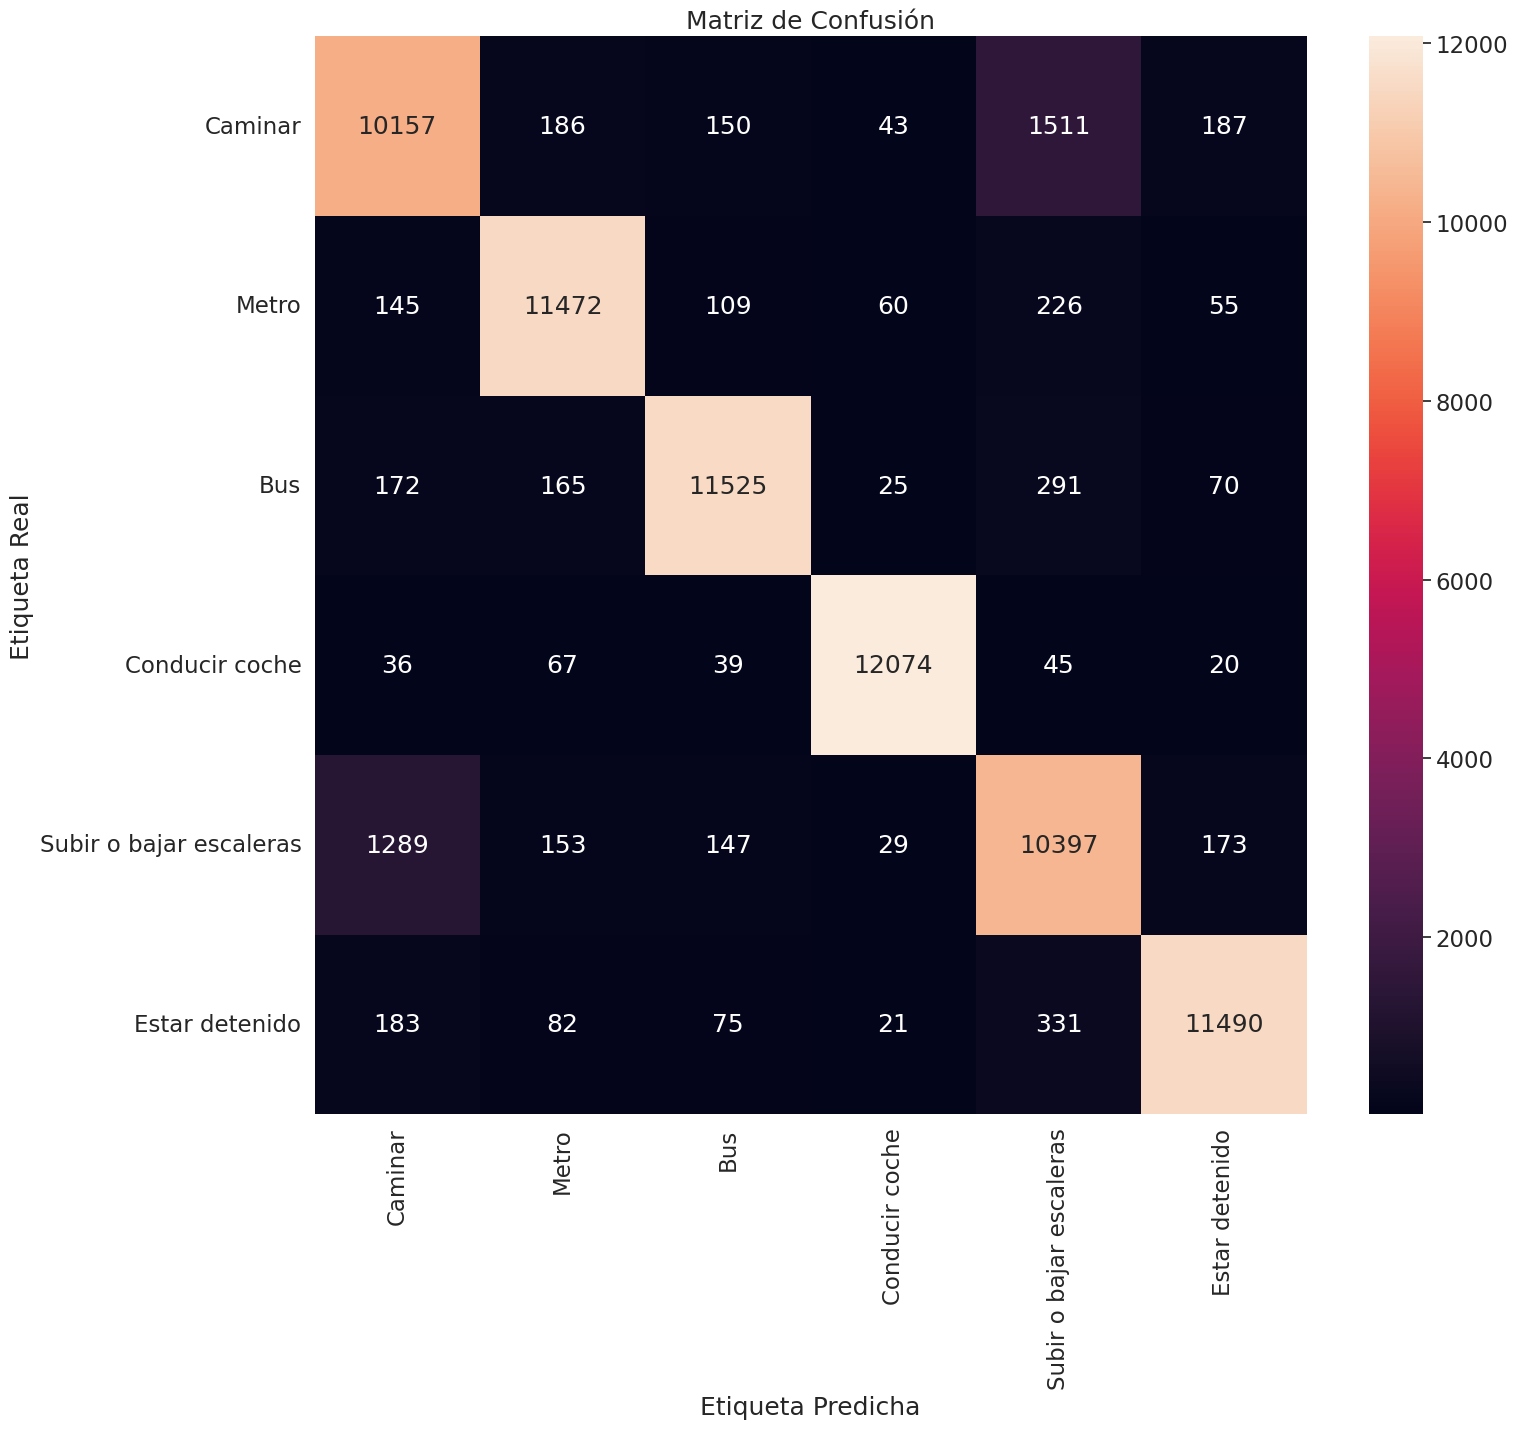

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Labels = ['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

# Calcular la matriz de confusión
confusion_matrix = confusion_matrix(y_true=y_test_classes, y_pred=y_pred)

plt.figure(figsize=(16, 14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True, fmt='d')
plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()


In [8]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_test_classes, return_counts=True)

#Imprimir el resultado
for valor, conteo, label in zip(valores, conteos, Labels):
    print(f"Valor: {valor}, Cantidad: {conteo}, Actividad: {label}")

Valor: 0, Cantidad: 12234, Actividad: Caminar
Valor: 1, Cantidad: 12067, Actividad: Metro
Valor: 2, Cantidad: 12248, Actividad: Bus
Valor: 3, Cantidad: 12281, Actividad: Conducir coche
Valor: 4, Cantidad: 12188, Actividad: Subir o bajar escaleras
Valor: 5, Cantidad: 12182, Actividad: Estar detenido


# Exportamos el modelo

In [9]:
import joblib

# Guardar el modelo GRU utilizando el método de Keras
model_GRU.save('../../Datos/Modelos/modelo_gru.h5')

# Guardar el codificador de etiquetas utilizando joblib
joblib.dump(label_encoder, '../../Datos/Label/label_encoder.pkl')

/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


['../../Datos/Label/label_encoder.pkl']